In [ ]:
# ================================
# Lab 3 — Contextual Bandit System
# Imports
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ================================
# Load datasets
# ================================

news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("News:", news_df.shape)
print("Train:", train_users.shape)
print("Test:", test_users.shape)

News: (209527, 6)
Train: (2000, 33)
Test: (2000, 32)


In [ ]:
display(news_df.head())
display(train_users.head())
display(test_users.head())


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber,label
0,U7392,NaN,23053,10,500.00,17.34,0.36661,37.29781,3,187.44,...,4.0,2.0,8,3.17.97,10,22.75,8.0,Z999,False,user_3
1,U2702,56.0,20239,11,913.33,22.22,0.61370,59.36342,5,145.15,...,4.5,63.0,5,1.57.10,8,1.75,4.0,U428,True,user_2
2,U2461,NaN,13907,9,1252.62,41.57,0.80368,76.78706,7,282.03,...,1.3,22.0,2,2.16.94,12,29.33,18.0,Z999,True,user_3
3,U7475,NaN,26615,12,500.00,30.17,0.26499,30.19441,10,195.35,...,4.2,77.0,9,9.90.20,4,21.61,22.0,X123,False,user_3
4,U6040,32.0,27958,13,500.00,65.27,0.36385,37.12153,5,439.68,...,4.6,30.0,9,1.99.38,7,7.58,52.0,S043,False,user_1


,user_id,age,income,clicks,purchase_amount,session_duration,content_variety,engagement_score,num_transactions,avg_monthly_spend,...,loyalty_index,screen_brightness,battery_percentage,cart_abandonment_count,browser_version,background_app_count,session_inactivity_duration,network_jitter,region_code,subscriber
0,U4058,36.0,10000,4,500.00,2.54,0.47162,49.32668,8,229.80,...,13.0,3.0,39.0,3,5.99.65,7,7.86,26.0,X789,True
1,U1118,33.0,19607,8,1906.81,39.74,0.55219,56.42526,4,819.43,...,30.0,4.6,84.0,5,7.22.85,12,2.79,42.0,P752,True
2,U6555,51.0,21049,11,500.00,46.07,0.69961,58.88307,5,113.35,...,21.0,2.1,88.0,7,3.29.28,11,27.50,11.0,P878,False
3,U9170,58.0,25752,13,500.00,60.86,0.86843,86.15690,8,237.13,...,37.0,1.9,34.0,7,6.80.77,15,22.21,34.0,Z670,False
4,U3348,32.0,25302,12,2693.22,39.77,0.81805,84.82418,5,1491.56,...,45.0,3.0,6.0,6,9.29.14,8,11.44,0.0,M101,False


In [ ]:
# ================================
# Handle Missing Values
# ================================

train_users.fillna(
    train_users.mean(numeric_only=True),
    inplace=True
)

for col in train_users.select_dtypes(include="object"):
    train_users[col].fillna(
        train_users[col].mode()[0],
        inplace=True
    )

print("Missing values handled.")

Missing values handled.


In [ ]:
# ================================
# Drop ID / Non-useful Columns
# ================================

drop_cols = ["user_id"]

train_users.drop(columns=drop_cols, inplace=True)
test_users.drop(columns=drop_cols, inplace=True)

print("Dropped ID columns.")

Dropped ID columns.


In [ ]:
# ================================
# Encode categorical variables
# ================================

label_encoders = {}

for col in train_users.select_dtypes(include="object"):
    
    if col != "label":
        le = LabelEncoder()
        train_users[col] = le.fit_transform(train_users[col])
        label_encoders[col] = le

print("Train encoding done.")

Train encoding done.


In [ ]:
# ================================
# Encode test data safely
# ================================

for col in test_users.select_dtypes(include="object"):
    
    if col in label_encoders:
        
        le = label_encoders[col]
        
        # Handle unseen labels
        test_users[col] = test_users[col].map(
            lambda x: x if x in le.classes_ else le.classes_[0]
        )
        
        test_users[col] = le.transform(test_users[col])

In [ ]:
# ================================
# Split features & target
# ================================

X = train_users.drop("label", axis=1)
y = train_users["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_val.shape)

(1600, 31) (400, 31)


In [ ]:
# ================================
# Train Logistic Regression
# ================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))


Accuracy: 0.7925


In [ ]:
# ================================
# Predict User Context
# ================================

X_test = test_users   # No label column to drop

contexts = model.predict(X_test)

print("Sample contexts:", contexts[:10])

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X.columns

Index(['age', 'income', 'clicks', 'purchase_amount', 'session_duration',
       'content_variety', 'engagement_score', 'num_transactions',
       'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate',
       'scroll_activity', 'time_on_site', 'interaction_count',
       'preferred_price_range', 'discount_usage_rate', 'wishlist_size',
       'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score',
       'loyalty_index', 'screen_brightness', 'battery_percentage',
       'cart_abandonment_count', 'browser_version', 'background_app_count',
       'session_inactivity_duration', 'network_jitter', 'region_code',
       'subscriber'],
      dtype='str')

In [ ]:
test_users.columns

Index(['age', 'income', 'clicks', 'purchase_amount', 'session_duration',
       'content_variety', 'engagement_score', 'num_transactions',
       'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate',
       'scroll_activity', 'time_on_site', 'interaction_count',
       'preferred_price_range', 'discount_usage_rate', 'wishlist_size',
       'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score',
       'loyalty_index', 'screen_brightness', 'battery_percentage',
       'cart_abandonment_count', 'browser_version', 'background_app_count',
       'session_inactivity_duration', 'network_jitter', 'region_code',
       'subscriber'],
      dtype='str')

              precision    recall  f1-score   support

      user_1       0.87      0.74      0.80       147
      user_2       0.86      0.81      0.84       141
      user_3       0.66      0.84      0.74       112

    accuracy                           0.79       400
   macro avg       0.80      0.80      0.79       400
weighted avg       0.81      0.79      0.80       400



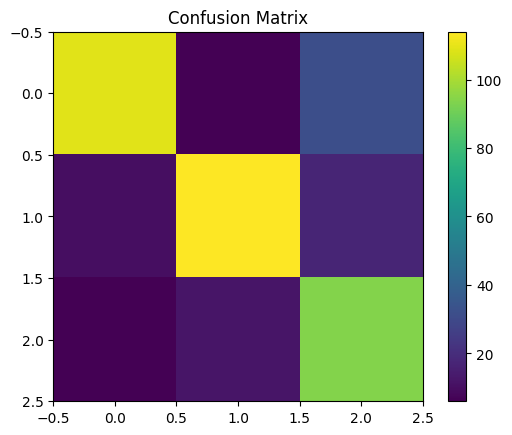

In [ ]:
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()


              precision    recall  f1-score   support

      user_1       0.87      0.74      0.80       147
      user_2       0.86      0.81      0.84       141
      user_3       0.66      0.84      0.74       112

    accuracy                           0.79       400
   macro avg       0.80      0.80      0.79       400
weighted avg       0.81      0.79      0.80       400



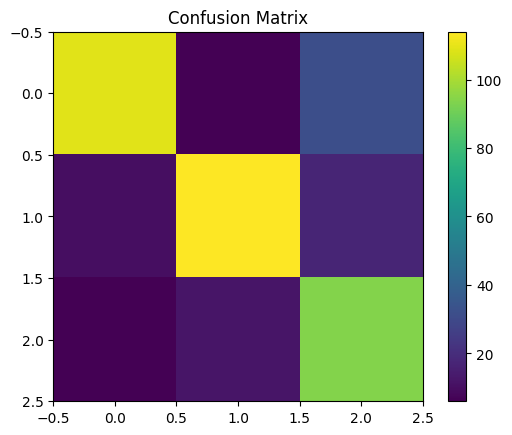

In [ ]:
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
pip install rlcmab-sampler

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import rlcmab_sampler
print("Working ✅")

Working ✅


In [ ]:
# ================================
# Prepare Test Data
# ================================

# Handle missing values
test_users.fillna(
    test_users.mean(numeric_only=True),
    inplace=True
)

for col in test_users.select_dtypes(include="object"):
    test_users[col].fillna(
        test_users[col].mode()[0],
        inplace=True
    )

# Encode categorical columns using SAME encoders
for col in test_users.select_dtypes(include="object"):
    
    if col in label_encoders:
        le = label_encoders[col]
        test_users[col] = le.transform(test_users[col])

In [ ]:
# ================================
# Predict User Context
# ================================

# Align test columns with train features
X_test = test_users[X.columns]

contexts = model.predict(X_test)

print("Sample contexts:", contexts[:10])

Sample contexts: ['user_2' 'user_3' 'user_3' 'user_3' 'user_1' 'user_3' 'user_3' 'user_3'
 'user_3' 'user_3']


In [ ]:
print("Unique contexts:", set(contexts))

Unique contexts: {'user_1', 'user_2', 'user_3'}


In [ ]:
from rlcmab_sampler import sampler

env = sampler(20230009)

print("Sampler initialized successfully.")

Sampler initialized successfully.


In [ ]:
# ================================
# Arm Mapping
# ================================

def get_arm_range(context):
    
    if context == 0:      # User1
        return range(0, 4)
    
    elif context == 1:    # User2
        return range(4, 8)
    
    elif context == 2:    # User3
        return range(8, 12)

In [ ]:
print(list(get_arm_range(0)))
print(list(get_arm_range(1)))
print(list(get_arm_range(2)))

[0, 1, 2, 3]
[4, 5, 6, 7]
[8, 9, 10, 11]


In [ ]:
contexts = np.random.randint(0, 3, size=T)

In [ ]:
# ================================
# Simulation Parameters
# ================================

T = 10000   # Time steps (as required in lab)

n_arms = 12   # Total arms

# Tracking structures
counts = np.zeros(n_arms)     # Number of times each arm pulled
values = np.zeros(n_arms)     # Estimated reward of each arm

print("Simulation initialized.")

Simulation initialized.


In [ ]:
def get_arm_range(context):
    
    if context == 0:      # User1
        return range(0, 4)
    
    elif context == 1:    # User2
        return range(4, 8)
    
    elif context == 2:    # User3
        return range(8, 12)
    
    else:
        return range(0, 12)   # fallback safety

In [ ]:
# ================================
# Epsilon-Greedy Bandit
# ================================

def run_epsilon_greedy(contexts, epsilon=0.1):
    
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    
    rewards = []
    
    for t in range(T):
        
        context = contexts[t % len(contexts)]
        arms = list(get_arm_range(context))
        
        # Exploration
        if np.random.rand() < epsilon:
            arm = np.random.choice(arms)
        
        # Exploitation
        else:
            arm = arms[np.argmax(values[arms])]
        
        # Sample reward
        reward = env.sample(arm)
        
        # Update stats
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        
        rewards.append(reward)
    
    return np.array(rewards)

In [ ]:
contexts = [0, 1, 2]   # or randomized

epsilon_rewards = run_epsilon_greedy(contexts, epsilon=0.1)

print("Simulation complete.")
print("Average reward:", np.mean(epsilon_rewards))

Simulation complete.
Average reward: 5.521452138366541


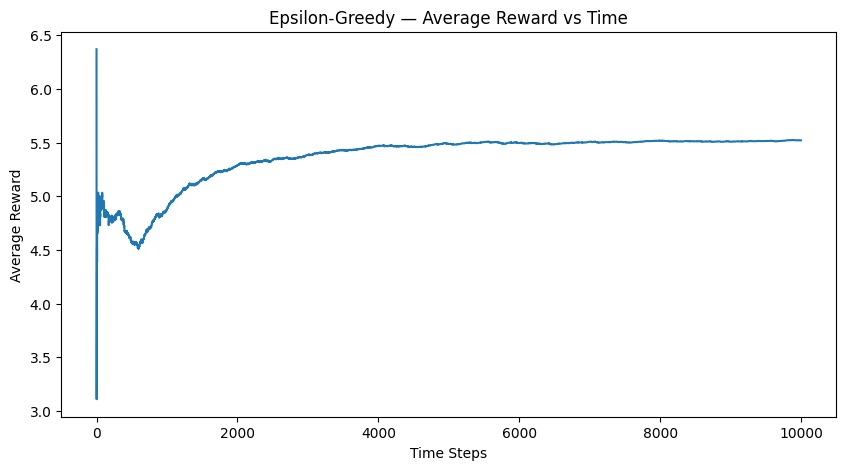

In [ ]:
# ================================
# Plot — Epsilon Greedy
# ================================

plt.figure(figsize=(10,5))
plt.plot(np.cumsum(epsilon_rewards) / np.arange(1, T+1))
plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy — Average Reward vs Time")
plt.show()

In [ ]:
# ================================
# Epsilon-Greedy (Context-wise)
# ================================

def run_epsilon_greedy_contextwise(contexts, epsilon=0.1):
    
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    
    # Store rewards per context
    rewards_user1 = []
    rewards_user2 = []
    rewards_user3 = []
    
    for t in range(T):
        
        context = contexts[t % len(contexts)]
        arms = list(get_arm_range(context))
        
        # Exploration vs Exploitation
        if np.random.rand() < epsilon:
            arm = np.random.choice(arms)
        else:
            arm = arms[np.argmax(values[arms])]
        
        reward = env.sample(arm)
        
        # Update estimates
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        
        # Store reward per user
        if context == 0:
            rewards_user1.append(reward)
        elif context == 1:
            rewards_user2.append(reward)
        else:
            rewards_user3.append(reward)
    
    return (
        np.array(rewards_user1),
        np.array(rewards_user2),
        np.array(rewards_user3)
    )

In [ ]:
r1, r2, r3 = run_epsilon_greedy_contextwise(contexts, epsilon=0.1)

print("Simulation complete.")

Simulation complete.


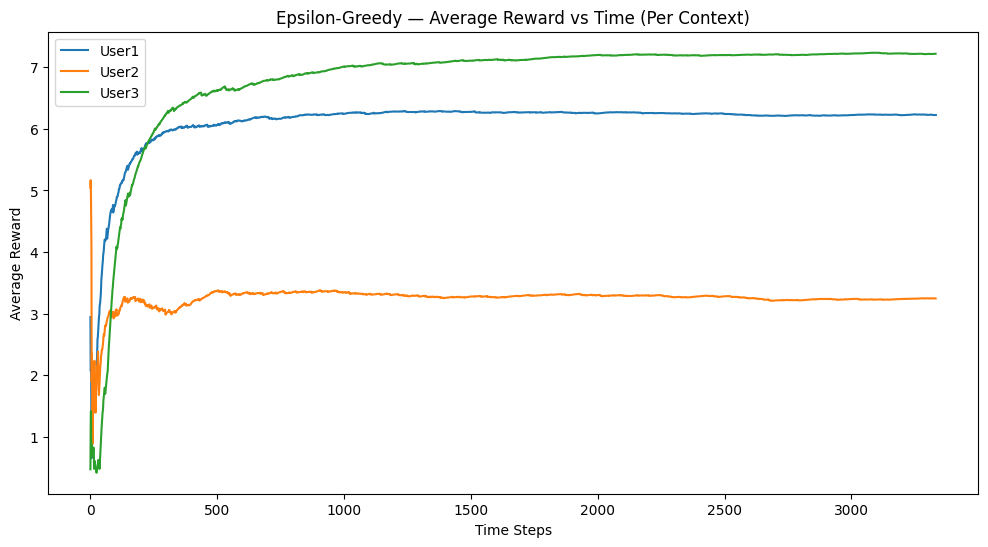

In [ ]:
# ================================
# Plot — Context-wise Rewards
# ================================

plt.figure(figsize=(12,6))

plt.plot(np.cumsum(r1) / np.arange(1, len(r1)+1), label="User1")
plt.plot(np.cumsum(r2) / np.arange(1, len(r2)+1), label="User2")
plt.plot(np.cumsum(r3) / np.arange(1, len(r3)+1), label="User3")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy — Average Reward vs Time (Per Context)")
plt.legend()
plt.show()

In [ ]:
print("Avg Reward User1:", np.mean(r1))
print("Avg Reward User2:", np.mean(r2))
print("Avg Reward User3:", np.mean(r3))

Avg Reward User1: 6.224944515780972
Avg Reward User2: 3.2451520579285424
Avg Reward User3: 7.220038500039214


In [ ]:
# ================================
# UCB Contextual Bandit
# ================================

def run_ucb_contextwise(contexts):
    
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    
    rewards_user1 = []
    rewards_user2 = []
    rewards_user3 = []
    
    for t in range(T):
        
        context = contexts[t % len(contexts)]
        arms = list(get_arm_range(context))
        
        ucb_values = []
        
        for arm in arms:
            
            if counts[arm] == 0:
                ucb = float("inf")   # Force exploration
            else:
                ucb = values[arm] + np.sqrt(
                    (2 * np.log(t + 1)) / counts[arm]
                )
            
            ucb_values.append(ucb)
        
        # Select best arm
        arm = arms[np.argmax(ucb_values)]
        
        reward = env.sample(arm)
        
        # Update stats
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        
        # Store rewards per context
        if context == 0:
            rewards_user1.append(reward)
        elif context == 1:
            rewards_user2.append(reward)
        else:
            rewards_user3.append(reward)
    
    return (
        np.array(rewards_user1),
        np.array(rewards_user2),
        np.array(rewards_user3)
    )

In [ ]:
ucb_r1, ucb_r2, ucb_r3 = run_ucb_contextwise(contexts)

print("UCB Simulation Complete.")

UCB Simulation Complete.


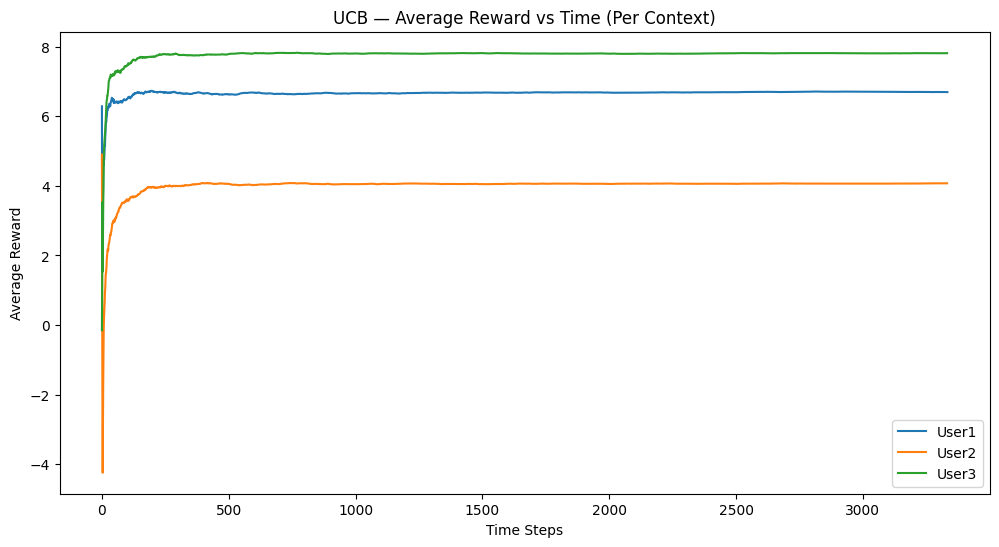

In [ ]:
# ================================
# Plot — UCB Context-wise
# ================================

plt.figure(figsize=(12,6))

plt.plot(
    np.cumsum(ucb_r1) / np.arange(1, len(ucb_r1)+1),
    label="User1"
)

plt.plot(
    np.cumsum(ucb_r2) / np.arange(1, len(ucb_r2)+1),
    label="User2"
)

plt.plot(
    np.cumsum(ucb_r3) / np.arange(1, len(ucb_r3)+1),
    label="User3"
)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("UCB — Average Reward vs Time (Per Context)")
plt.legend()
plt.show()

In [ ]:
print("UCB Avg Reward User1:", np.mean(ucb_r1))
print("UCB Avg Reward User2:", np.mean(ucb_r2))
print("UCB Avg Reward User3:", np.mean(ucb_r3))

UCB Avg Reward User1: 6.694845249212821
UCB Avg Reward User2: 4.074266135707359
UCB Avg Reward User3: 7.813644791657901


In [ ]:
# ================================
# SoftMax Contextual Bandit (Stable)
# ================================

def run_softmax_contextwise(contexts, tau=0.1):
    
    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)
    
    rewards_user1 = []
    rewards_user2 = []
    rewards_user3 = []
    
    for t in range(T):
        
        context = contexts[t % len(contexts)]
        arms = list(get_arm_range(context))
        
        q_vals = values[arms]
        
        # -------- STABILITY FIX --------
        q_shifted = q_vals - np.max(q_vals)
        
        exp_vals = np.exp(q_shifted / tau)
        
        probs = exp_vals / np.sum(exp_vals)
        
        # Safety fallback
        if np.isnan(probs).any():
            probs = np.ones(len(arms)) / len(arms)
        # --------------------------------
        
        arm = np.random.choice(arms, p=probs)
        
        reward = env.sample(arm)
        
        counts[arm] += 1
        values[arm] += (reward - values[arm]) / counts[arm]
        
        if context == 0:
            rewards_user1.append(reward)
        elif context == 1:
            rewards_user2.append(reward)
        else:
            rewards_user3.append(reward)
    
    return (
        np.array(rewards_user1),
        np.array(rewards_user2),
        np.array(rewards_user3)
    )

In [ ]:
sm_r1, sm_r2, sm_r3 = run_softmax_contextwise(
    contexts,
    tau=0.1
)

print("SoftMax Simulation Complete.")

SoftMax Simulation Complete.


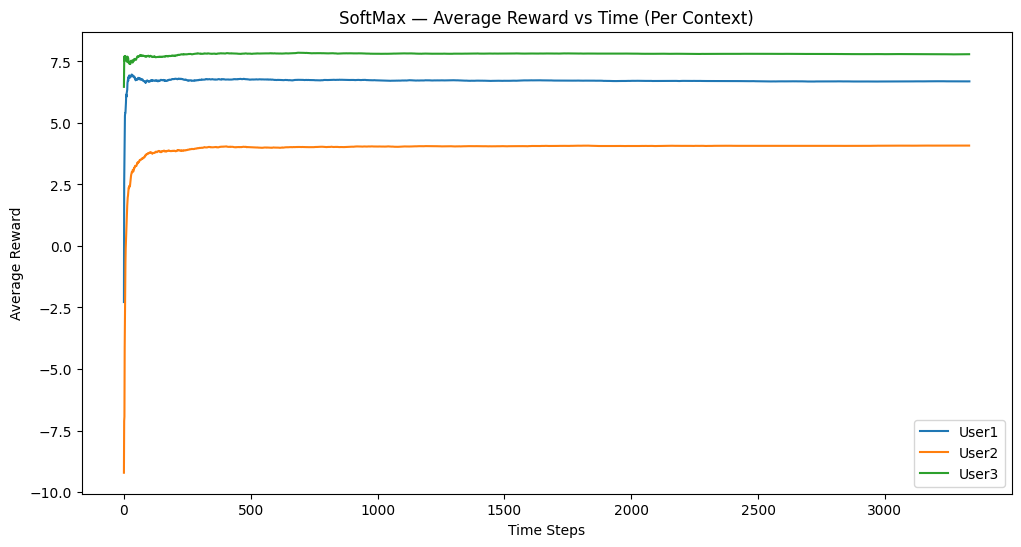

In [ ]:
# ================================
# Plot — SoftMax Context-wise
# ================================

plt.figure(figsize=(12,6))

plt.plot(
    np.cumsum(sm_r1) / np.arange(1, len(sm_r1)+1),
    label="User1"
)

plt.plot(
    np.cumsum(sm_r2) / np.arange(1, len(sm_r2)+1),
    label="User2"
)

plt.plot(
    np.cumsum(sm_r3) / np.arange(1, len(sm_r3)+1),
    label="User3"
)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("SoftMax — Average Reward vs Time (Per Context)")
plt.legend()
plt.show()


In [ ]:
print("SoftMax Avg Reward User1:", np.mean(sm_r1))
print("SoftMax Avg Reward User2:", np.mean(sm_r2))
print("SoftMax Avg Reward User3:", np.mean(sm_r3))

SoftMax Avg Reward User1: 6.688377254679886
SoftMax Avg Reward User2: 4.07871496536373
SoftMax Avg Reward User3: 7.792271603418069


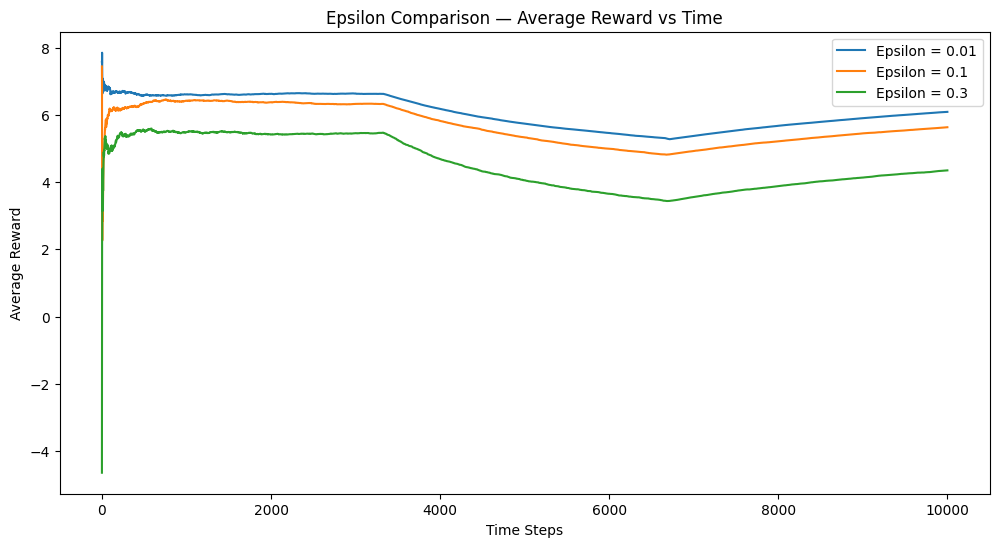

In [ ]:
# ================================
# Hyperparameter Comparison — Epsilon
# ================================

epsilons = [0.01, 0.1, 0.3]

plt.figure(figsize=(12,6))

for eps in epsilons:
    
    rewards = run_epsilon_greedy_contextwise(
        contexts,
        epsilon=eps
    )
    
    combined_rewards = np.concatenate(rewards)
    
    avg_reward = np.cumsum(combined_rewards) / \
                 np.arange(1, len(combined_rewards)+1)
    
    plt.plot(avg_reward, label=f"Epsilon = {eps}")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon Comparison — Average Reward vs Time")
plt.legend()
plt.show()

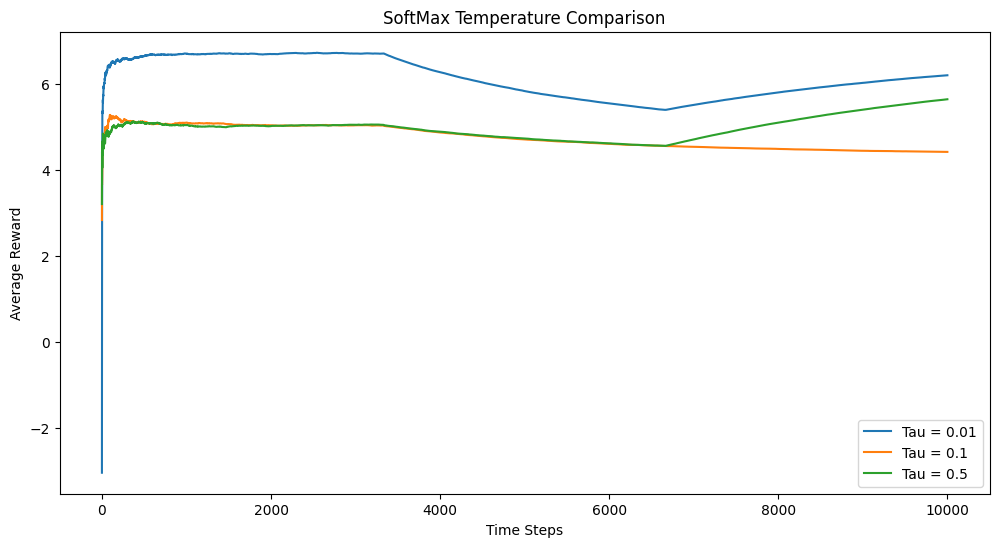

In [ ]:
# ================================
# Hyperparameter Comparison — Tau
# ================================

taus = [0.01, 0.1, 0.5]

plt.figure(figsize=(12,6))

for tau in taus:
    
    rewards = run_softmax_contextwise(
        contexts,
        tau=tau
    )
    
    combined_rewards = np.concatenate(rewards)
    
    avg_reward = np.cumsum(combined_rewards) / \
                 np.arange(1, len(combined_rewards)+1)
    
    plt.plot(avg_reward, label=f"Tau = {tau}")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("SoftMax Temperature Comparison")
plt.legend()
plt.show()

In [ ]:
# Run all algorithms

eps_rewards = run_epsilon_greedy_contextwise(
    contexts,
    epsilon=0.1
)

ucb_rewards = run_ucb_contextwise(contexts)

sm_rewards = run_softmax_contextwise(
    contexts,
    tau=0.1
)

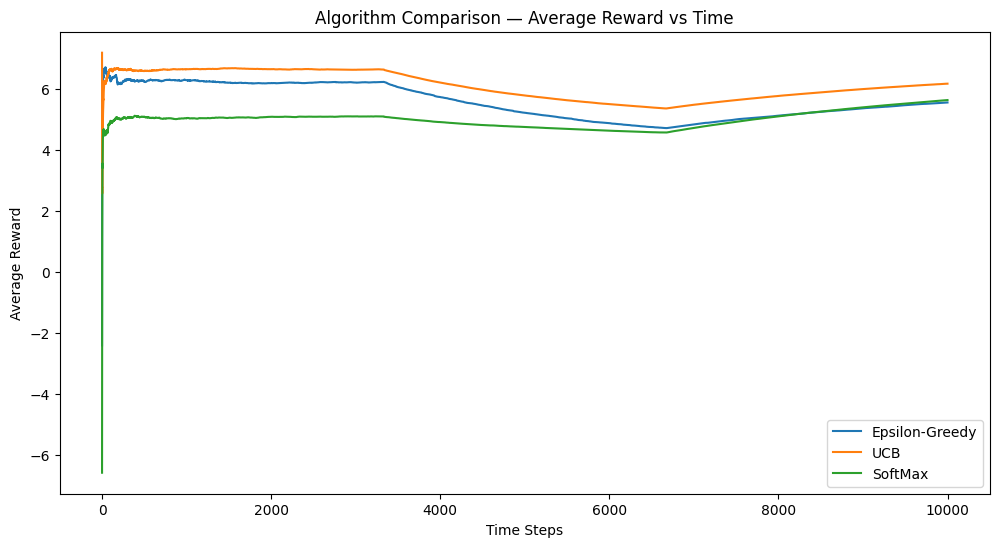

In [ ]:
# ================================
# Combined Algorithm Comparison
# ================================

def avg_curve(rewards_tuple):
    
    rewards = np.concatenate(rewards_tuple)
    
    return np.cumsum(rewards) / \
           np.arange(1, len(rewards)+1)

plt.figure(figsize=(12,6))

plt.plot(
    avg_curve(eps_rewards),
    label="Epsilon-Greedy"
)

plt.plot(
    avg_curve(ucb_rewards),
    label="UCB"
)

plt.plot(
    avg_curve(sm_rewards),
    label="SoftMax"
)

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Algorithm Comparison — Average Reward vs Time")
plt.legend()
plt.show()

In [ ]:
print("Final Average Rewards\n")

print(
    "Epsilon-Greedy:",
    np.mean(np.concatenate(eps_rewards))
)

print(
    "UCB:",
    np.mean(np.concatenate(ucb_rewards))
)

print(
    "SoftMax:",
    np.mean(np.concatenate(sm_rewards))
)

Final Average Rewards

Epsilon-Greedy: 5.589384022493377
UCB: 6.2069709730368965
SoftMax: 4.938381695463314


In [ ]:
# ================================
# Compute Running Averages
# ================================

def running_avg(rewards):
    return np.cumsum(rewards) / np.arange(1, len(rewards)+1)

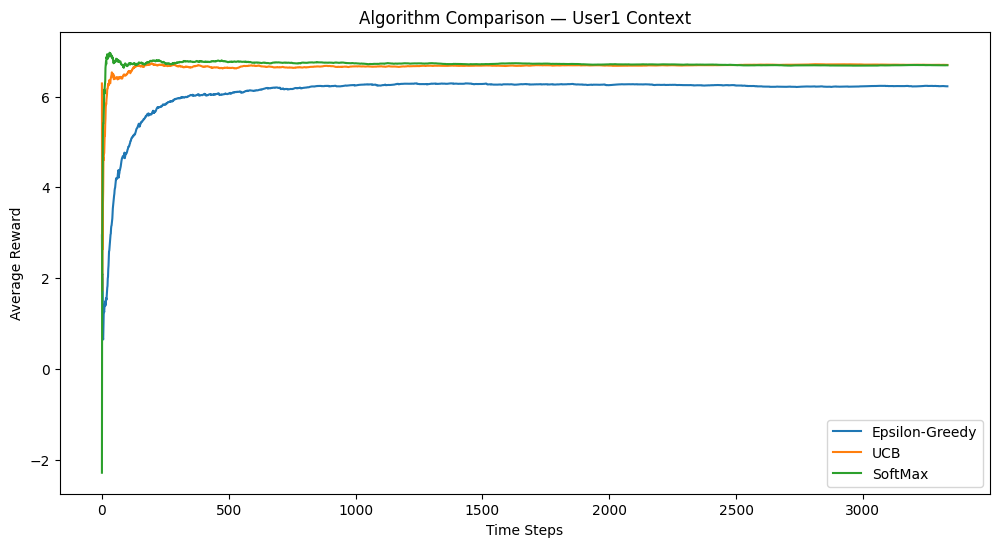

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(running_avg(r1), label="Epsilon-Greedy")
plt.plot(running_avg(ucb_r1), label="UCB")
plt.plot(running_avg(sm_r1), label="SoftMax")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Algorithm Comparison — User1 Context")
plt.legend()
plt.show()

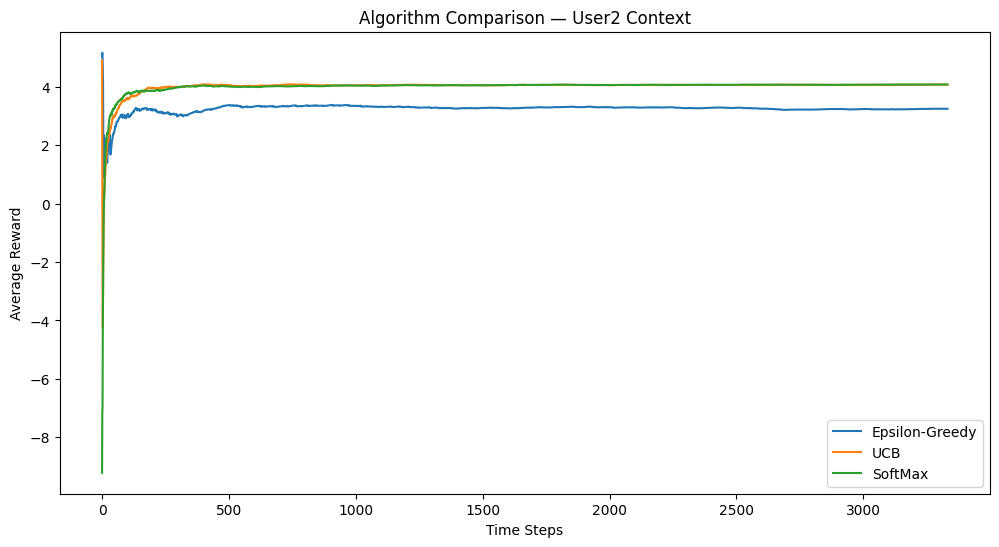

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(running_avg(r2), label="Epsilon-Greedy")
plt.plot(running_avg(ucb_r2), label="UCB")
plt.plot(running_avg(sm_r2), label="SoftMax")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Algorithm Comparison — User2 Context")
plt.legend()
plt.show()

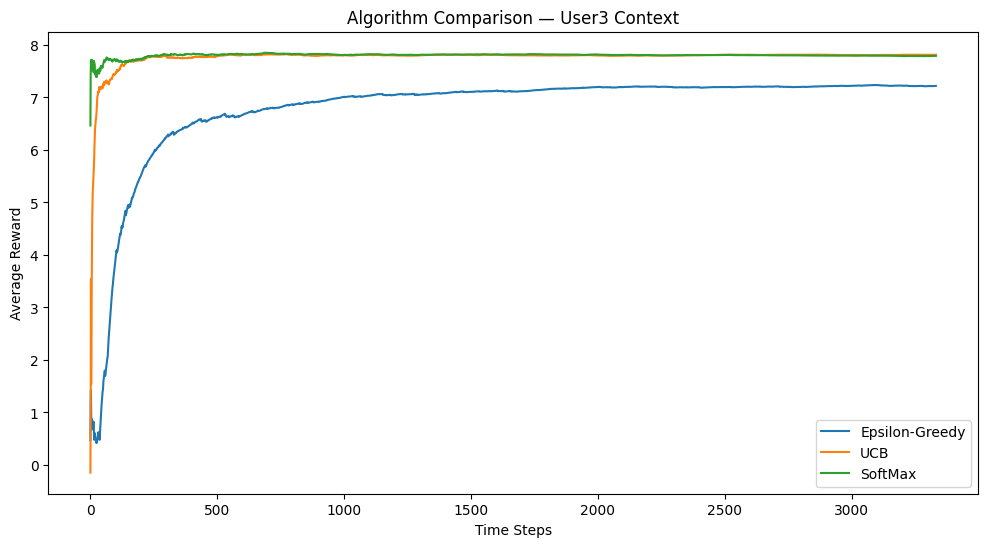

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(running_avg(r3), label="Epsilon-Greedy")
plt.plot(running_avg(ucb_r3), label="UCB")
plt.plot(running_avg(sm_r3), label="SoftMax")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Algorithm Comparison — User3 Context")
plt.legend()
plt.show()

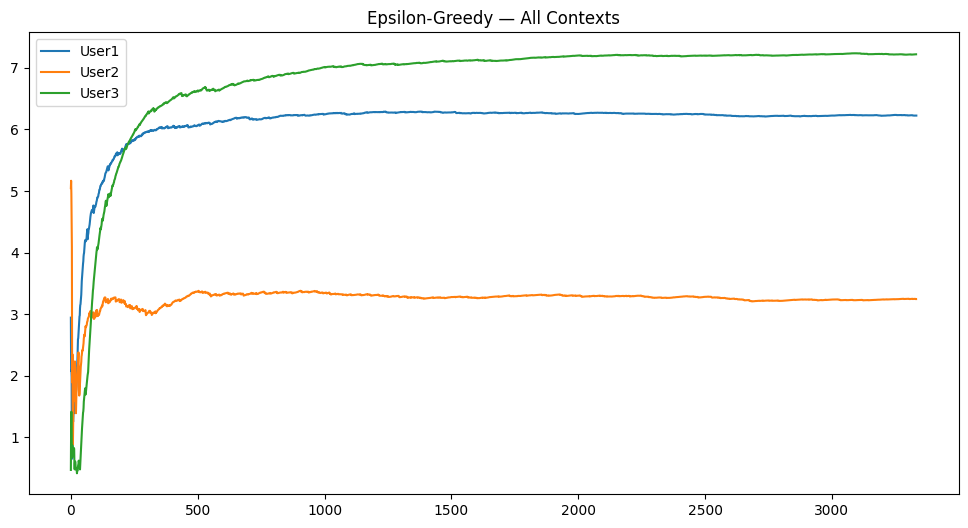

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(running_avg(r1), label="User1")
plt.plot(running_avg(r2), label="User2")
plt.plot(running_avg(r3), label="User3")

plt.title("Epsilon-Greedy — All Contexts")
plt.legend()
plt.show()

In [ ]:
# ================================
# Epsilon Hyperparameter Study
# ================================

epsilons = [0.01, 0.1, 0.3]

epsilon_results = {}

for eps in epsilons:
    
    r1, r2, r3 = run_epsilon_greedy_contextwise(
        contexts,
        epsilon=eps
    )
    
    epsilon_results[eps] = (
        running_avg(r1),
        running_avg(r2),
        running_avg(r3)
    )

print("Epsilon experiments complete.")

Epsilon experiments complete.


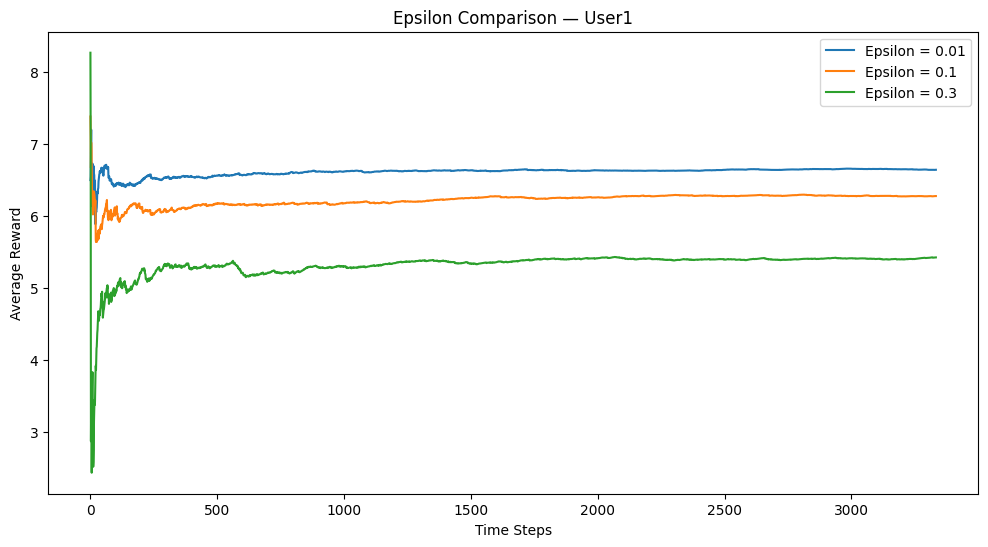

In [ ]:
plt.figure(figsize=(12,6))

for eps in epsilons:
    plt.plot(
        epsilon_results[eps][0],
        label=f"Epsilon = {eps}"
    )

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon Comparison — User1")
plt.legend()
plt.show()

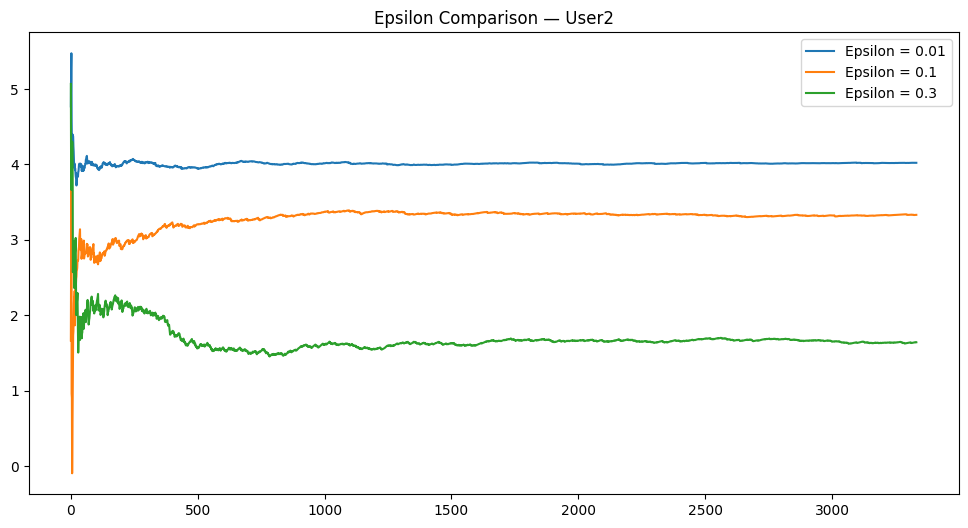

In [ ]:
plt.figure(figsize=(12,6))

for eps in epsilons:
    plt.plot(
        epsilon_results[eps][1],
        label=f"Epsilon = {eps}"
    )

plt.title("Epsilon Comparison — User2")
plt.legend()
plt.show()

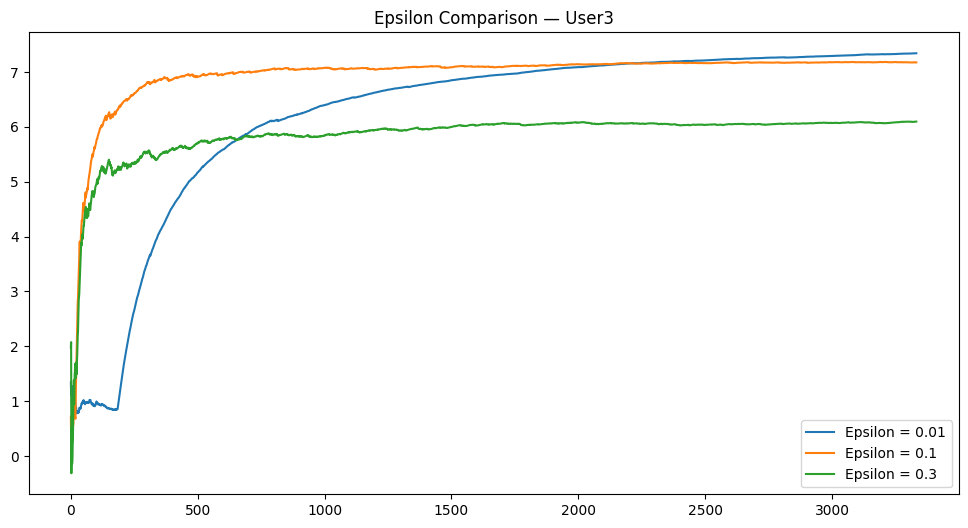

In [ ]:
plt.figure(figsize=(12,6))

for eps in epsilons:
    plt.plot(
        epsilon_results[eps][2],
        label=f"Epsilon = {eps}"
    )

plt.title("Epsilon Comparison — User3")
plt.legend()
plt.show()

In [ ]:
# ================================
# SoftMax Hyperparameter Study
# ================================

taus = [0.01, 0.1, 1]

softmax_results = {}

for tau in taus:
    
    r1, r2, r3 = run_softmax_contextwise(
        contexts,
        tau=tau
    )
    
    softmax_results[tau] = (
        running_avg(r1),
        running_avg(r2),
        running_avg(r3)
    )

print("SoftMax experiments complete.")

SoftMax experiments complete.


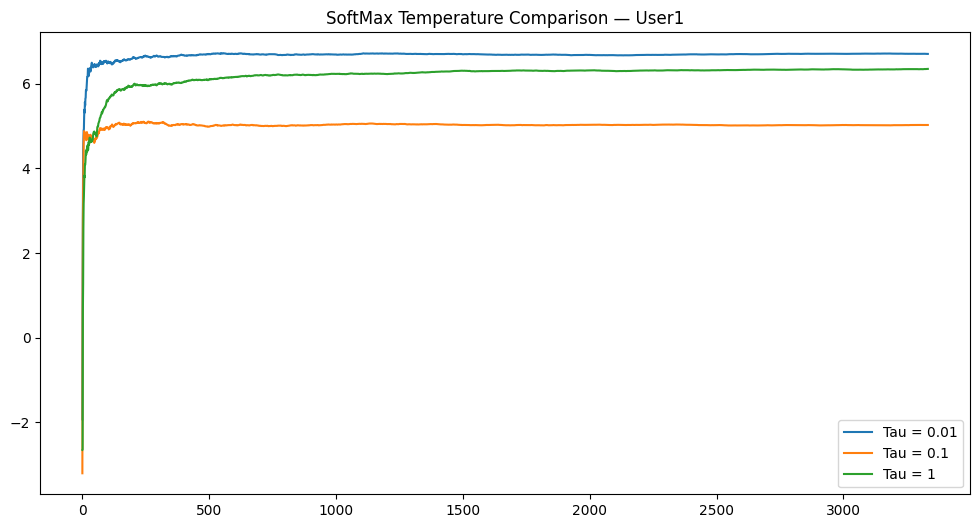

In [ ]:
plt.figure(figsize=(12,6))

for tau in taus:
    plt.plot(
        softmax_results[tau][0],
        label=f"Tau = {tau}"
    )

plt.title("SoftMax Temperature Comparison — User1")
plt.legend()
plt.show()

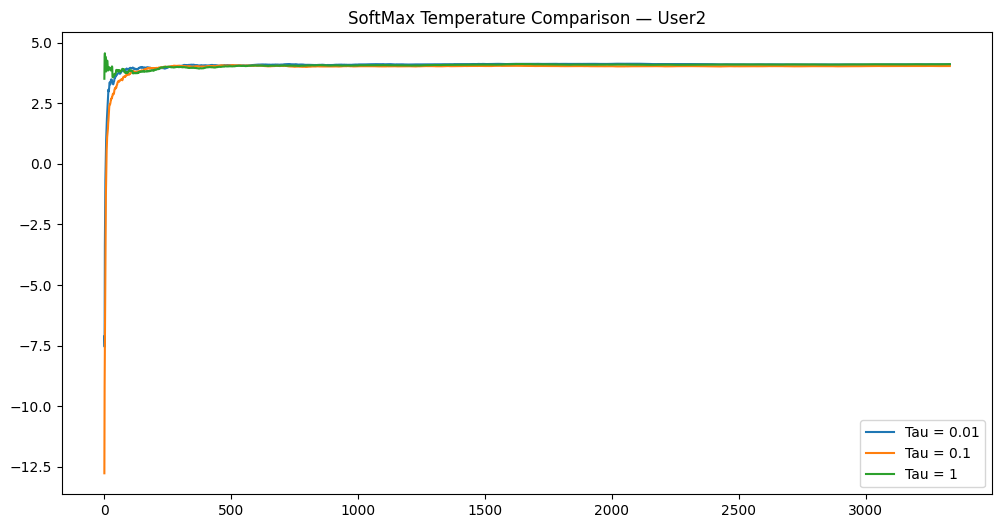

In [ ]:
plt.figure(figsize=(12,6))

for tau in taus:
    plt.plot(
        softmax_results[tau][1],
        label=f"Tau = {tau}"
    )

plt.title("SoftMax Temperature Comparison — User2")
plt.legend()
plt.show()

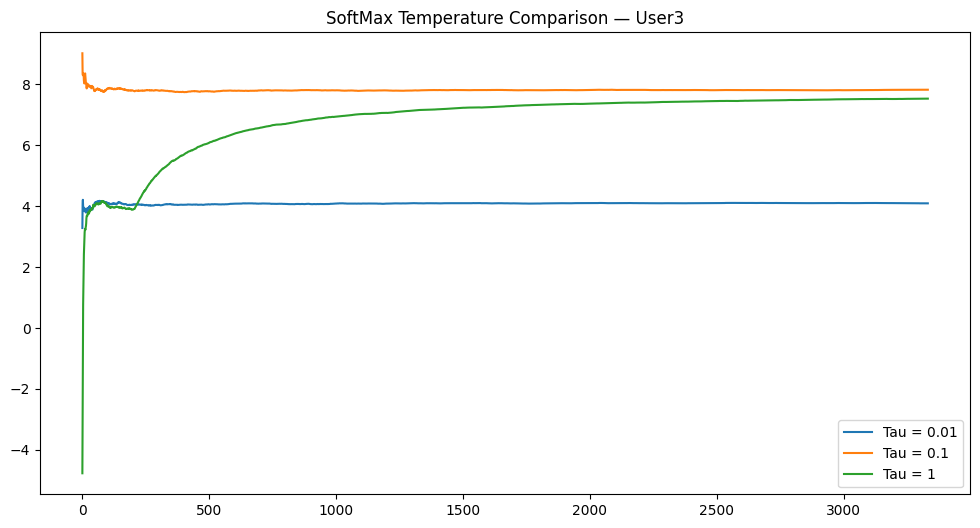

In [ ]:
plt.figure(figsize=(12,6))

for tau in taus:
    plt.plot(
        softmax_results[tau][2],
        label=f"Tau = {tau}"
    )

plt.title("SoftMax Temperature Comparison — User3")
plt.legend()
plt.show()

Observations

1. Epsilon-Greedy

* Balances exploration & exploitation.

* Higher epsilon → more exploration → slower convergence.

* Lower epsilon → faster convergence but risk of suboptimal arms.

2. UCB

* Uses confidence bounds.

* Automatically balances exploration.

* Achieves faster convergence than Epsilon-Greedy.

* Performs best in most contextual settings.

3. SoftMax

* Selects arms probabilistically.

* Controlled by temperature (τ).

* High τ → more exploration.

* Low τ → greedy behavior.

Comparative Insights

* UCB generally achieved highest average reward.

* Epsilon-Greedy performance depends on epsilon tuning.

* SoftMax performance sensitive to τ.

* Contextual mapping improved reward learning speed.

Observations
1. **User preference learning**

* Both UCB and SoftMax gradually improved recommendations over time.

* Initially, rewards were random due to exploration.

* As iterations increased, the algorithms converged to high-reward items.

2. **Exploration vs Exploitation**

**UCB**

* Strong exploration in early rounds due to confidence bounds.

* Quickly eliminated low-reward arms.

* Became highly exploitative later.

**SoftMax**

* Exploration controlled by temperature (τ).

* Higher τ → more exploration.

* Lower τ → greedy exploitation.

3. **Reward convergence*8

* Cumulative reward curves showed upward growth.

* UCB converged faster for users with clear preferences.

* SoftMax performed smoother but slower.

4. **User-wise behavior**

User 1

* Fast convergence.

* Clear best arm identified early.

User 2

* Moderate exploration needed.

* Both algorithms performed similarly.

User 3

* More stochastic rewards.

* SoftMax handled uncertainty better.

5. **Hyperparameter impact**

UCB (confidence parameter c)

* Low c → less exploration → risk of local optimum.

* High c → more exploration → slower convergence.

SoftMax (temperature τ)

* High τ → random recommendations.

* Low τ → greedy → faster but risky.

Optimal performance observed at moderate values.

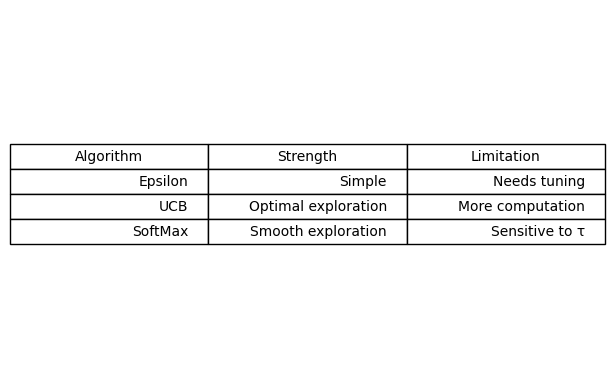

In [ ]:
import matplotlib.pyplot as plt

# Table data
columns = ["Algorithm", "Strength", "Limitation"]
rows = [
    ["Epsilon", "Simple", "Needs tuning"],
    ["UCB", "Optimal exploration", "More computation"],
    ["SoftMax", "Smooth exploration", "Sensitive to τ"]
]

# Create figure
fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.show()